In [2]:
import os

print(os.listdir("/kaggle/input/datasets/nsree2405/severity/severity"))

['CRC_Grade__2__Mod_Diff', 'CRC_Grade__3__Poorly_Diff', 'Normal_Colon', 'CRC_Grade__1__Well_Diff']


In [ ]:
import torch, gc

gc.collect()
torch.cuda.empty_cache()

In [3]:
# ============================================================
# ✅ ONE CELL: COPY + CLEAN DATASET (KAGGLE SAFE)
# ============================================================

import os
import shutil
from PIL import Image

SRC = "/kaggle/input/datasets/nsree2405/severity/severity"
DST = "/kaggle/working/severity_clean"

print("🚀 Starting dataset preparation...\n")

# ============================================================
# STEP 1: COPY DATASET (only if not already copied)
# ============================================================
if not os.path.exists(DST):
    print("📂 Copying dataset to working directory...")
    shutil.copytree(SRC, DST)
    print("✅ Copy complete!\n")
else:
    print("📂 Dataset already copied. Skipping copy...\n")

# ============================================================
# STEP 2: REMOVE CORRUPTED IMAGES
# ============================================================
print("🔍 Scanning and cleaning corrupted images...\n")

total = 0
corrupted = 0

for root, dirs, files in os.walk(DST):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            path = os.path.join(root, file)
            total += 1

            try:
                img = Image.open(path)
                img.verify()  # check corruption

            except Exception:
                corrupted += 1
                print(f"❌ Removing corrupted: {path}")
                try:
                    os.remove(path)
                except:
                    print(f"⚠️ Could not delete: {path}")

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n============================================================")
print(f"📊 Total images checked: {total}")
print(f"❌ Corrupted images removed: {corrupted}")
print(f"✅ Clean images remaining: {total - corrupted}")
print("============================================================")

# ============================================================
# FINAL PATH TO USE IN TRAINING
# ============================================================
DATASET_PATH = DST
print(f"\n✅ USE THIS PATH FOR TRAINING:\n{DATASET_PATH}")

🚀 Starting dataset preparation...

📂 Copying dataset to working directory...
✅ Copy complete!

🔍 Scanning and cleaning corrupted images...

❌ Removing corrupted: /kaggle/working/severity_clean/CRC_Grade__3__Poorly_Diff/20x/07_CRC_G3_20154_20x_2.jpg
❌ Removing corrupted: /kaggle/working/severity_clean/CRC_Grade__3__Poorly_Diff/20x/20_CRC_G3_230433_20x_2.jpg
❌ Removing corrupted: /kaggle/working/severity_clean/CRC_Grade__2__Mod_Diff/20x/10_CRC_G2_20224_20x_3.jpg
❌ Removing corrupted: /kaggle/working/severity_clean/CRC_Grade__2__Mod_Diff/20x/20_CRC_G2_18486_20x_3.jpg
❌ Removing corrupted: /kaggle/working/severity_clean/CRC_Grade__2__Mod_Diff/4x/68_CRC_G2_230469_4x_1.jpg

📊 Total images checked: 1907
❌ Corrupted images removed: 5
✅ Clean images remaining: 1902

✅ USE THIS PATH FOR TRAINING:
/kaggle/working/severity_clean


2026-03-27 15:27:07,752 - INFO - ============================================================
2026-03-27 15:27:07,753 - INFO - STEP 1: LOADING DATASET
2026-03-27 15:27:07,753 - INFO - ============================================================
2026-03-27 15:27:07,754 - INFO - Classes: ['CRC_Grade__1__Well_Diff', 'CRC_Grade__2__Mod_Diff', 'CRC_Grade__3__Poorly_Diff', 'Normal_Colon']
2026-03-27 15:27:07,757 - INFO - CRC_Grade__1__Well_Diff → 860
2026-03-27 15:27:07,760 - INFO - CRC_Grade__2__Mod_Diff → 709
2026-03-27 15:27:07,761 - INFO - CRC_Grade__3__Poorly_Diff → 325
2026-03-27 15:27:07,763 - INFO - Normal_Colon → 8
2026-03-27 15:27:07,763 - INFO - Total samples: 1902
2026-03-27 15:27:07,766 - INFO - ✓ Train: 1331
2026-03-27 15:27:07,767 - INFO - ✓ Val: 285
2026-03-27 15:27:07,767 - INFO - ✓ Test: 286
2026-03-27 15:27:07,768 - INFO - ============================================================
2026-03-27 15:27:07,769 - INFO - STEP 2: BUILDING MODEL
2026-03-27 15:27:07,770 - INFO - ==


📊 Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.91      0.91       128
           1       0.92      0.84      0.88       106
           2       0.83      0.96      0.89        50
           3       0.67      1.00      0.80         2

    accuracy                           0.89       286
   macro avg       0.83      0.93      0.87       286
weighted avg       0.90      0.89      0.89       286



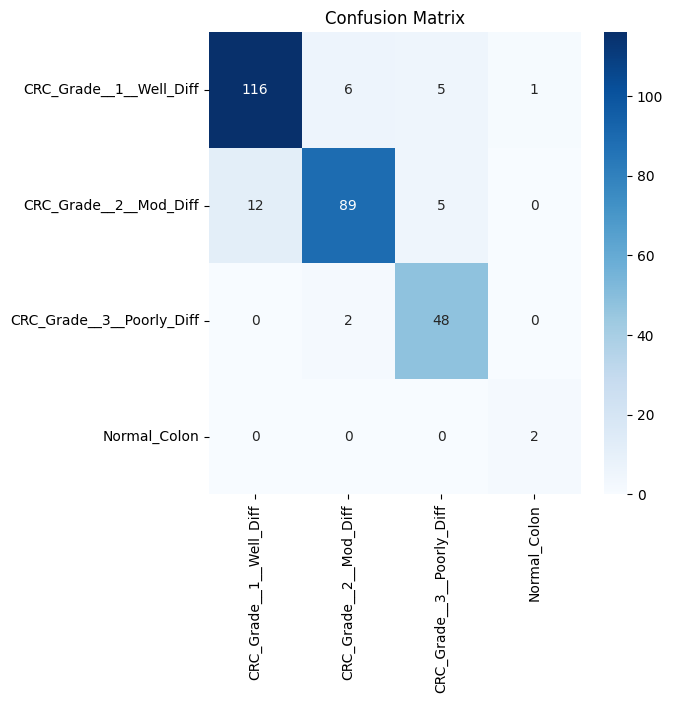


✅ Model saved at: /kaggle/working/severity_model.pth
✅ Confusion matrix saved at: /kaggle/working/confusion_matrix.png


In [5]:
# ============================================================
# COLON CANCER SEVERITY GRADING (FINAL OBJECTIVE)
# ============================================================

import os, logging, random
import numpy as np
from PIL import Image, ImageFile
from tqdm import tqdm

ImageFile.LOAD_TRUNCATED_IMAGES = True

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torch.amp import autocast, GradScaler

import torchvision.transforms as transforms
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import seaborn as sns
import matplotlib.pyplot as plt

# ==============================
# CONFIG
# ==============================
DATASET_PATH = "/kaggle/working/severity_clean"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16
EPOCHS = 16
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

# ==============================
# DATASET (ROBUST)
# ==============================
class ColonDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.paths = []
        self.labels = []
        self.transform = transform

        logging.info("============================================================")
        logging.info("STEP 1: LOADING DATASET")
        logging.info("============================================================")

        classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(classes)}

        logging.info(f"Classes: {classes}")

        for cls in classes:
            cls_path = os.path.join(root_dir, cls)
            count = 0

            for root, _, files in os.walk(cls_path):
                for f in files:
                    if f.lower().endswith((".jpg", ".png", ".jpeg")):
                        self.paths.append(os.path.join(root, f))
                        self.labels.append(self.class_to_idx[cls])
                        count += 1

            logging.info(f"{cls} → {count}")

        logging.info(f"Total samples: {len(self.paths)}")

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img_path = self.paths[idx]

        try:
            img = Image.open(img_path).convert("RGB")
        except Exception:
            # 🔥 FIX: handle corrupted images safely
            print(f"⚠️ Skipping corrupted image: {img_path}")
            img = Image.new("RGB", (224, 224))

        if self.transform:
            img = self.transform(img)

        return img, self.labels[idx]

# ==============================
# TRANSFORMS
# ==============================
train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

test_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

# ==============================
# LOAD DATA
# ==============================
dataset = ColonDataset(DATASET_PATH, transform=train_tf)

if len(dataset) == 0:
    raise ValueError("❌ Dataset empty!")

indices = np.arange(len(dataset))

train_idx, temp_idx = train_test_split(indices, test_size=0.3, random_state=SEED)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=SEED)

train_set = Subset(dataset, train_idx)
val_set   = Subset(dataset, val_idx)
test_set  = Subset(dataset, test_idx)

logging.info(f"✓ Train: {len(train_set)}")
logging.info(f"✓ Val: {len(val_set)}")
logging.info(f"✓ Test: {len(test_set)}")

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_set, batch_size=BATCH_SIZE)

# ==============================
# MODEL
# ==============================
logging.info("============================================================")
logging.info("STEP 2: BUILDING MODEL")
logging.info("============================================================")

weights = EfficientNet_V2_S_Weights.DEFAULT
model = efficientnet_v2_s(weights=weights)

num_classes = len(dataset.class_to_idx)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
model = model.to(DEVICE)

# ==============================
# LOSS (IMBALANCE HANDLING)
# ==============================
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(dataset.labels),
    y=dataset.labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

# 🔥 AMP FIX (new API)
scaler = GradScaler()

# ==============================
# TRAINING
# ==============================
logging.info("============================================================")
logging.info("STEP 3: TRAINING")
logging.info("============================================================")

best_acc = 0

for epoch in range(EPOCHS):
    model.train()
    correct = 0

    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()

        with autocast(device_type='cuda'):
            out = model(x)
            loss = criterion(out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        correct += (out.argmax(1) == y).sum().item()

    train_acc = correct / len(train_set)

    # VALIDATION
    model.eval()
    correct = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            correct += (out.argmax(1) == y).sum().item()

    val_acc = correct / len(val_set)

    logging.info(f"Epoch {epoch+1} | Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}%")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "/kaggle/working/severity_model.pth")
        logging.info("✓ Best model saved")

logging.info(f"\n✓ Training complete! Best Val Acc: {best_acc*100:.2f}%")

# ==============================
# TESTING
# ==============================
logging.info("============================================================")
logging.info("STEP 4: TESTING")
logging.info("============================================================")

model.load_state_dict(torch.load("/kaggle/working/severity_model.pth"))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for x, y in tqdm(test_loader):
        x = x.to(DEVICE)
        out = model(x)

        preds = out.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

print("\n📊 Classification Report:\n")
print(classification_report(all_labels, all_preds))

# ==============================
# CONFUSION MATRIX
# ==============================
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(dataset.class_to_idx.keys()),
            yticklabels=list(dataset.class_to_idx.keys()))
plt.title("Confusion Matrix")
plt.savefig("/kaggle/working/confusion_matrix.png")
plt.show()

print("\n✅ Model saved at: /kaggle/working/severity_model.pth")
print("✅ Confusion matrix saved at: /kaggle/working/confusion_matrix.png")